<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/hyperparamters_tuning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The optuna is applied to get apply the hyperparameters tuning and best than the grid search for the small data and the random search cv have random values some time miss the important details but the optuna is the best version for the production level work

In [1]:
import kagglehub
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.


In [2]:
import pandas as pd

movies_path = f"{path}/tmdb_5000_movies.csv"
df = pd.read_csv(movies_path)
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [5]:
df.isnull().sum()

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Get all object columns
string_cols = df.select_dtypes(include='object').columns.tolist()

converted_cols_info = []

# --- Handle 'original_language' and 'status' (Label Encoding) ---
for col in ['original_language', 'status']:
    if col in string_cols:
        le = LabelEncoder()
        # Convert to string first to handle potential NaNs consistently, though these columns appear clean
        df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
        converted_cols_info.append(f"'{col}' was label encoded into '{col}_encoded'.")
        string_cols.remove(col)

# --- Handle 'release_date' (Unix Timestamp) ---
if 'release_date' in string_cols:
    # Convert to datetime, coercing errors to NaT, then to Unix timestamp (integer in seconds)
    df['release_date_timestamp'] = pd.to_datetime(df['release_date'], errors='coerce').astype('int64') // 10**9
    converted_cols_info.append(f"'release_date' was converted to Unix timestamp in 'release_date_timestamp'.")
    string_cols.remove('release_date')

# --- Provide information on remaining string columns ---
if len(string_cols) > 0:
    remaining_info = "The following string columns were not directly converted to integers because they contain complex data (JSON-like strings or free text) that require more specific parsing or feature engineering:\n"
    for col in string_cols:
        remaining_info += f"- '{col}'\n"
    remaining_info += "Please specify if you'd like to perform specific operations on these columns (e.g., extract IDs from JSON, perform text analysis, or one-hot encode parsed values)."
    converted_cols_info.append(remaining_info)

# Display a summary of changes
print("String column conversion summary:")
for info in converted_cols_info:
    print(info)

# Display info about the DataFrame to show new columns and types
print("\nUpdated DataFrame info:")
df.info()

String column conversion summary:
'original_language' was label encoded into 'original_language_encoded'.
'status' was label encoded into 'status_encoded'.
'release_date' was converted to Unix timestamp in 'release_date_timestamp'.
The following string columns were not directly converted to integers because they contain complex data (JSON-like strings or free text) that require more specific parsing or feature engineering:
- 'genres'
- 'homepage'
- 'keywords'
- 'original_title'
- 'overview'
- 'production_companies'
- 'production_countries'
- 'spoken_languages'
- 'tagline'
- 'title'
Please specify if you'd like to perform specific operations on these columns (e.g., extract IDs from JSON, perform text analysis, or one-hot encode parsed values).

Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0 

In [11]:
# Fill nulls in object columns with 'unknown'
df['homepage'].fillna('unknown', inplace=True)
df['overview'].fillna('unknown', inplace=True)
df['tagline'].fillna('unknown', inplace=True)
df['release_date'].fillna('unknown', inplace=True)
df['status'].fillna('unknown', inplace=True)
df['original_language'].fillna('unknown', inplace=True)

print(df.isnull().sum())

budget                       0
genres                       0
homepage                     0
id                           0
keywords                     0
original_language            0
original_title               0
overview                     0
popularity                   0
production_companies         0
production_countries         0
release_date                 0
revenue                      0
runtime                      0
spoken_languages             0
status                       0
tagline                      0
title                        0
vote_average                 0
vote_count                   0
original_language_encoded    0
status_encoded               0
release_date_timestamp       0
dtype: int64


/tmp/ipykernel_2644/104150402.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['release_date'].fillna('unknown', inplace=True)
/tmp/ipykernel_2644/104150402.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [14]:
!pip install optuna
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

# --- 1. Data Preparation ---

# Create a binary target variable for classification
# Let's predict if the movie's vote_average is above or equal to 7.0
df['high_vote_average'] = (df['vote_average'] >= 7.0).astype(int)
y = df['high_vote_average']

# Select features: numerical and previously encoded categorical features
X = df[[
    'budget', 'id', 'popularity', 'revenue', 'runtime', 'vote_count',
    'original_language_encoded', 'status_encoded', 'release_date_timestamp'
]].copy()

# Handle potential NaN values in features (e.g., from release_date_timestamp conversion if errors occurred)
X.fillna(X.mean(numeric_only=True), inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 2. Define Objective Function for Optuna ---
def objective(trial):
    # Hyperparameters to tune for Decision Tree Classifier
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 2, 32, log=True)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Initialize Decision Tree Classifier with suggested hyperparameters
    model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    # Use cross-validation to evaluate the model
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')

    # Return the mean accuracy (Optuna minimizes by default, so we want to maximize accuracy)
    return scores.mean()

# --- 3. Run Optimization ---
print("Starting Optuna hyperparameter optimization for Decision Tree...")
study = optuna.create_study(direction='maximize') # We want to maximize accuracy
study.optimize(objective, n_trials=50) # Run 50 trials

# --- 4. Display Results ---
print("\nOptuna optimization finished.")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
trial = study.best_trial

print(f"  Value: {trial.value:.4f}")
print(f"  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# Train a final model with the best hyperparameters on the full training set
best_model = DecisionTreeClassifier(**trial.params, random_state=42)
best_model.fit(X_train, y_train)

# Evaluate the best model on the test set
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of the best model on the test set: {test_accuracy:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.2 MB/s eta 0:00:00


[I 2026-06-17 21:54:13,121] A new study created in memory with name: no-name-9a204317-3c29-41f0-a001-9336c7e397ed


Starting Optuna hyperparameter optimization for Decision Tree...


[I 2026-06-17 21:54:13,404] Trial 0 finished with value: 0.8076458875162549 and parameters: {'criterion': 'entropy', 'max_depth': 23, 'min_samples_split': 5, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.8076458875162549.
[I 2026-06-17 21:54:13,534] Trial 1 finished with value: 0.8125938041829215 and parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.8125938041829215.
[I 2026-06-17 21:54:13,642] Trial 2 finished with value: 0.8144167208495883 and parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.8144167208495883.
[I 2026-06-17 21:54:13,733] Trial 3 finished with value: 0.805566956545297 and parameters: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 11, 'min_samples_leaf': 10}. Best is trial 2 with value: 0.8144167208495883.
[I 2026-06-17 21:54:13,909] Trial 4 finished with value: 0.8295117441482445 and paramete


Optuna optimization finished.
Number of finished trials: 50
Best trial:
  Value: 0.8332
  Params: 
    criterion: entropy
    max_depth: 8
    min_samples_split: 10
    min_samples_leaf: 10

Accuracy of the best model on the test set: 0.8439



--- Optuna Optimization Visualizations ---



--- Decision Tree Model Visualizations ---


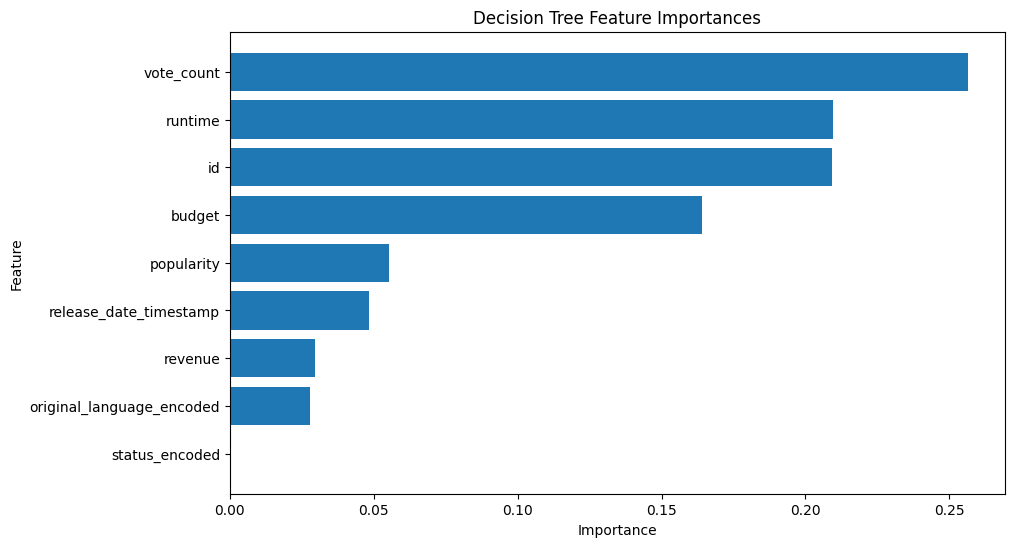

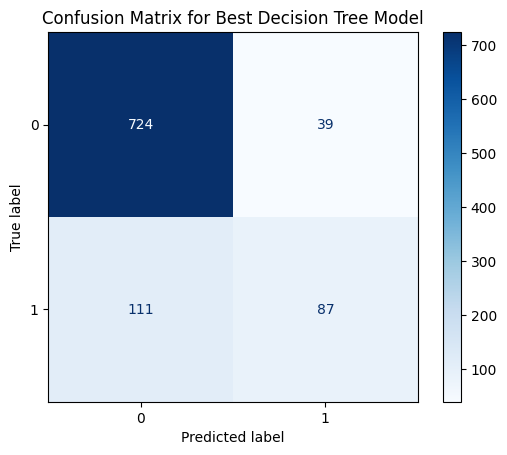

In [15]:
import matplotlib.pyplot as plt
import optuna.visualization as ov
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\n--- Optuna Optimization Visualizations ---")

# 1. Optimization History Plot
# This plot shows the objective value (accuracy) for each trial over time.
ov.plot_optimization_history(study).show()

# 2. Parallel Coordinate Plot
# This plot visualizes the hyperparameter relationships with the objective value.
ov.plot_parallel_coordinate(study).show()

print("\n--- Decision Tree Model Visualizations ---")

# 3. Feature Importance Plot
# Extract feature importances from the best model
feature_importances = best_model.feature_importances_
features = X_train.columns

# Create a DataFrame for better plotting
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Feature Importances')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

# 4. Confusion Matrix
# Generate the confusion matrix for the test set
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best Decision Tree Model')
plt.show()

# apply the mutli modal concept in the optuna

In [16]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

# Reuse X_train, y_train, X_test, y_test from previous steps

# --- 1. Optuna for Logistic Regression ---
print("\n--- Optuna for Logistic Regression ---")
def objective_lr(trial):
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'sag', 'saga'])
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    C = trial.suggest_float('C', 0.001, 10.0, log=True)

    # 'l1' penalty only works with 'liblinear' and 'saga'
    if solver == 'lbfgs' and penalty == 'l1':
        raise optuna.exceptions.TrialPruned()
    if solver == 'sag' and penalty == 'l1':
        raise optuna.exceptions.TrialPruned()

    model = LogisticRegression(
        solver=solver,
        penalty=penalty,
        C=C,
        random_state=42,
        max_iter=1000 # Increase max_iter for convergence
    )
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
    return scores.mean()

study_lr = optuna.create_study(direction='maximize', study_name='LogisticRegression_Optimization')
study_lr.optimize(objective_lr, n_trials=30) # Fewer trials for LR

print("Best trial (Logistic Regression):")
trial_lr = study_lr.best_trial
print(f"  Value: {trial_lr.value:.4f}")
print(f"  Params: {trial_lr.params}")

best_lr_model = LogisticRegression(**trial_lr.params, random_state=42, max_iter=1000)
best_lr_model.fit(X_train, y_train)
y_pred_lr = best_lr_model.predict(X_test)
test_accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy of the best Logistic Regression model on the test set: {test_accuracy_lr:.4f}")


# --- 2. Optuna for Random Forest Classifier ---
print("\n--- Optuna for Random Forest Classifier ---")
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 5, 20, log=False)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42,
        n_jobs=-1 # Use all available cores
    )
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
    return scores.mean()

study_rf = optuna.create_study(direction='maximize', study_name='RandomForest_Optimization')
study_rf.optimize(objective_rf, n_trials=50) # More trials for RF

print("Best trial (Random Forest):")
trial_rf = study_rf.best_trial
print(f"  Value: {trial_rf.value:.4f}")
print(f"  Params: {trial_rf.params}")

best_rf_model = RandomForestClassifier(**trial_rf.params, random_state=42, n_jobs=-1)
best_rf_model.fit(X_train, y_train)
y_pred_rf = best_rf_model.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of the best Random Forest model on the test set: {test_accuracy_rf:.4f}")


# --- 3. Optuna for Gradient Boosting Classifier ---
print("\n--- Optuna for Gradient Boosting Classifier ---")
def objective_gb(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
    return scores.mean()

study_gb = optuna.create_study(direction='maximize', study_name='GradientBoosting_Optimization')
study_gb.optimize(objective_gb, n_trials=50)

print("Best trial (Gradient Boosting):")
trial_gb = study_gb.best_trial
print(f"  Value: {trial_gb.value:.4f}")
print(f"  Params: {trial_gb.params}")

best_gb_model = GradientBoostingClassifier(**trial_gb.params, random_state=42)
best_gb_model.fit(X_train, y_train)
y_pred_gb = best_gb_model.predict(X_test)
test_accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Accuracy of the best Gradient Boosting model on the test set: {test_accuracy_gb:.4f}")

[I 2026-06-17 22:12:15,631] A new study created in memory with name: LogisticRegression_Optimization
[I 2026-06-17 22:12:15,634] Trial 0 pruned. 



--- Optuna for Logistic Regression ---


[I 2026-06-17 22:12:20,150] Trial 1 finished with value: 0.8032286248374513 and parameters: {'solver': 'sag', 'penalty': 'l2', 'C': 0.054926396688265364}. Best is trial 1 with value: 0.8032286248374513.
[I 2026-06-17 22:12:20,261] Trial 2 finished with value: 0.8029685468140443 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.006551549943963478}. Best is trial 1 with value: 0.8032286248374513.
[I 2026-06-17 22:12:22,806] Trial 3 finished with value: 0.8029682081707847 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.020361914740525584}. Best is trial 1 with value: 0.8032286248374513.
[I 2026-06-17 22:12:22,898] Trial 4 finished with value: 0.8344613540312095 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.002647186963572312}. Best is trial 4 with value: 0.8344613540312095.
[I 2026-06-17 22:12:22,958] Trial 5 finished with value: 0.8029685468140443 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 1.444040309527948}. Best is trial 4 w

Best trial (Logistic Regression):
  Value: 0.8360
  Params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.028581878718861243}
Accuracy of the best Logistic Regression model on the test set: 0.8283

--- Optuna for Random Forest Classifier ---


[I 2026-06-17 22:12:36,272] Trial 0 finished with value: 0.8521564802774165 and parameters: {'n_estimators': 129, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 0 with value: 0.8521564802774165.
[I 2026-06-17 22:12:42,834] Trial 1 finished with value: 0.8526756203944517 and parameters: {'n_estimators': 103, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 3, 'criterion': 'entropy'}. Best is trial 1 with value: 0.8526756203944517.
[I 2026-06-17 22:12:48,911] Trial 2 finished with value: 0.8547582764412656 and parameters: {'n_estimators': 67, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 4, 'criterion': 'entropy'}. Best is trial 2 with value: 0.8547582764412656.
[I 2026-06-17 22:12:55,504] Trial 3 finished with value: 0.8511161681837885 and parameters: {'n_estimators': 192, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 2 with value: 0.8547582764412656.


Best trial (Random Forest):
  Value: 0.8548
  Params: {'n_estimators': 163, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 1, 'criterion': 'gini'}


[I 2026-06-17 22:16:39,453] A new study created in memory with name: GradientBoosting_Optimization


Accuracy of the best Random Forest model on the test set: 0.8543

--- Optuna for Gradient Boosting Classifier ---


[I 2026-06-17 22:17:07,558] Trial 0 finished with value: 0.8407055970957955 and parameters: {'n_estimators': 198, 'learning_rate': 0.018790133811151032, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.8407055970957955.
[I 2026-06-17 22:17:28,741] Trial 1 finished with value: 0.8438265333766797 and parameters: {'n_estimators': 147, 'learning_rate': 0.2785539502182119, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.8438265333766797.
[I 2026-06-17 22:17:42,816] Trial 2 finished with value: 0.8396625758560902 and parameters: {'n_estimators': 115, 'learning_rate': 0.02592051933541613, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.8438265333766797.
[I 2026-06-17 22:17:44,759] Trial 3 finished with value: 0.8542374431079324 and parameters: {'n_estimators': 50, 'learning_rate': 0.1653833135166228, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf

Best trial (Gradient Boosting):
  Value: 0.8542
  Params: {'n_estimators': 50, 'learning_rate': 0.1653833135166228, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 3}
Accuracy of the best Gradient Boosting model on the test set: 0.8481
